# Sentiment Analysis – Google Play Store Apps Dataset

**Task:** Build a sentiment analysis pipeline that derives sentiment from app ratings and app names, classifies reviews as Positive / Neutral / Negative, and trains a text-based classifier using NLP.

**Dataset:** `apps.csv` — 9,660 Google Play Store apps with columns: `App`, `Category`, `Rating`, `Reviews`, `Size`, `Installs`, `Type`, `Price`, `Content Rating`, `Genres`, `Last Updated`, `Current Ver`, `Android Ver`

---
### Pipeline Overview
| Step | Description |
|------|-------------|
| 1 | Import & Data Loading |
| 2 | Data Cleaning & Preprocessing |
| 3 | Sentiment Labeling from Ratings |
| 4 | NLP Feature Engineering (TF-IDF on App Names) |
| 5 | Model Training (Naive Bayes, SVM) |
| 6 | Model Evaluation |
| 7 | Data Visualization |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP tools
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ML models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Wordcloud
from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Dataset & Initial Inspection

In [2]:
# Load the dataset
df = pd.read_csv('apps.csv', index_col=0)

print(f'Shape: {df.shape}')
df.head()

Shape: (9659, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
# Check dtypes and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   object 
 1   Category        9659 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            8432 non-null   object 
 5   Installs        9659 non-null   object 
 6   Type            9658 non-null   object 
 7   Price           9659 non-null   object 
 8   Content Rating  9659 non-null   object 
 9   Genres          9659 non-null   object 
 10  Last Updated    9659 non-null   object 
 11  Current Ver     9651 non-null   object 
 12  Android Ver     9657 non-null   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.0+ MB


In [4]:
# Null counts per column
df.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

## 3. Data Cleaning & Preprocessing

In [5]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Drop rows where Rating or App name is missing (critical columns)
df.dropna(subset=['Rating', 'App'], inplace=True)

# Convert Rating to float and filter valid range [1, 5]
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df[(df['Rating'] >= 1.0) & (df['Rating'] <= 5.0)].copy()

# Clean Reviews column — remove commas and convert to int
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce').fillna(0).astype(int)

# Clean Installs column — remove '+' and commas, cast to int
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce').fillna(0).astype(int)

# Clean Price column — remove '$' symbol and cast to float
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').fillna(0.0)

print(f'Shape after cleaning: {df.shape}')
df[['App', 'Rating', 'Reviews', 'Installs', 'Price']].head()

Shape after cleaning: (8196, 13)


,App,Rating,Reviews,Installs,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,10000,0.0
1,Coloring book moana,3.9,967,500000,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510,5000000,0.0
3,Sketch - Draw & Paint,4.5,215644,50000000,0.0
4,Pixel Draw - Number Art Coloring Book,4.3,967,100000,0.0


## 4. Sentiment Labeling from Ratings

> Since we don't have raw review text, we derive sentiment from `Rating`:
> - **Positive** → Rating ≥ 4.0
> - **Neutral** → 3.0 ≤ Rating < 4.0
> - **Negative** → Rating < 3.0

In [6]:
def label_sentiment(rating):
    if rating >= 4.0:
        return 'Positive'
    elif rating >= 3.0:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Rating'].apply(label_sentiment)

print('Sentiment distribution:')
print(df['Sentiment'].value_counts())

Sentiment distribution:
Sentiment
Positive    6286
Neutral     1631
Negative     279
Name: count, dtype: int64


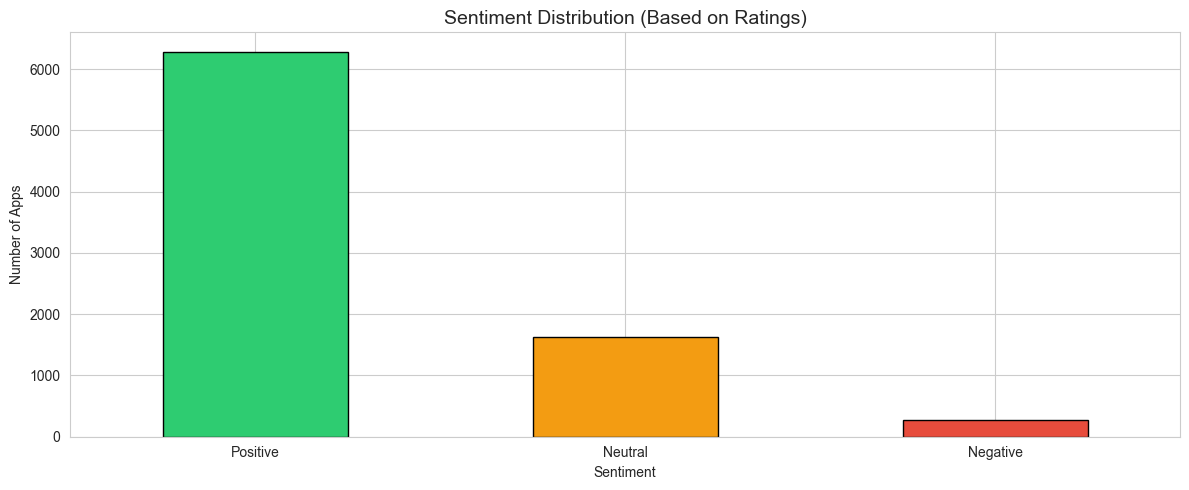

In [7]:
# Visualize sentiment class distribution
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['Sentiment'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Sentiment Distribution (Based on Ratings)', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Apps')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

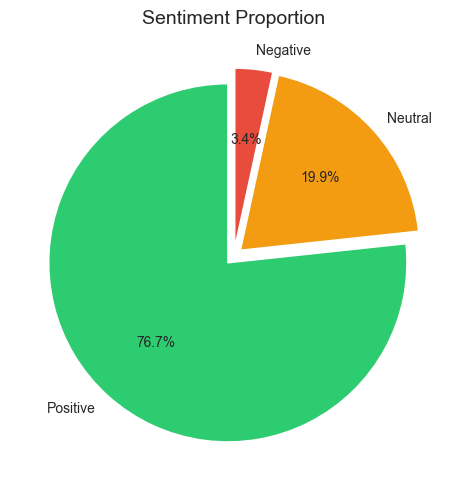

In [8]:
# Pie chart for sentiment proportion
df['Sentiment'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90,
    colors=['#2ecc71', '#f39c12', '#e74c3c'], explode=[0.05, 0.05, 0.05]
)
plt.title('Sentiment Proportion', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. NLP Feature Engineering

> We use `App` name as our text feature. Real-world sentiment analysis would use actual review text — here we demonstrate the full NLP pipeline on app names + genres as a proxy.

### 5.1 Text Cleaning

In [9]:
def clean_text(text):
    """Lowercase, remove special chars and extra whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # keep alphanumeric
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Combine App name + Genres as the text feature
df['text_feature'] = (
    df['App'].fillna('') + ' ' +
    df['Genres'].fillna('') + ' ' +
    df['Category'].fillna('')
)
df['text_feature'] = df['text_feature'].apply(clean_text)

df[['App', 'text_feature', 'Sentiment']].head()

,App,text_feature,Sentiment
0,Photo Editor & Candy Camera & Grid & ScrapBook,photo editor candy camera grid scrapbook art d...,Positive
1,Coloring book moana,coloring book moana art design pretend play ar...,Neutral
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",u launcher lite free live cool themes hide app...,Positive
3,Sketch - Draw & Paint,sketch draw paint art design art and design,Positive
4,Pixel Draw - Number Art Coloring Book,pixel draw number art coloring book art design...,Positive


### 5.2 Word Cloud per Sentiment

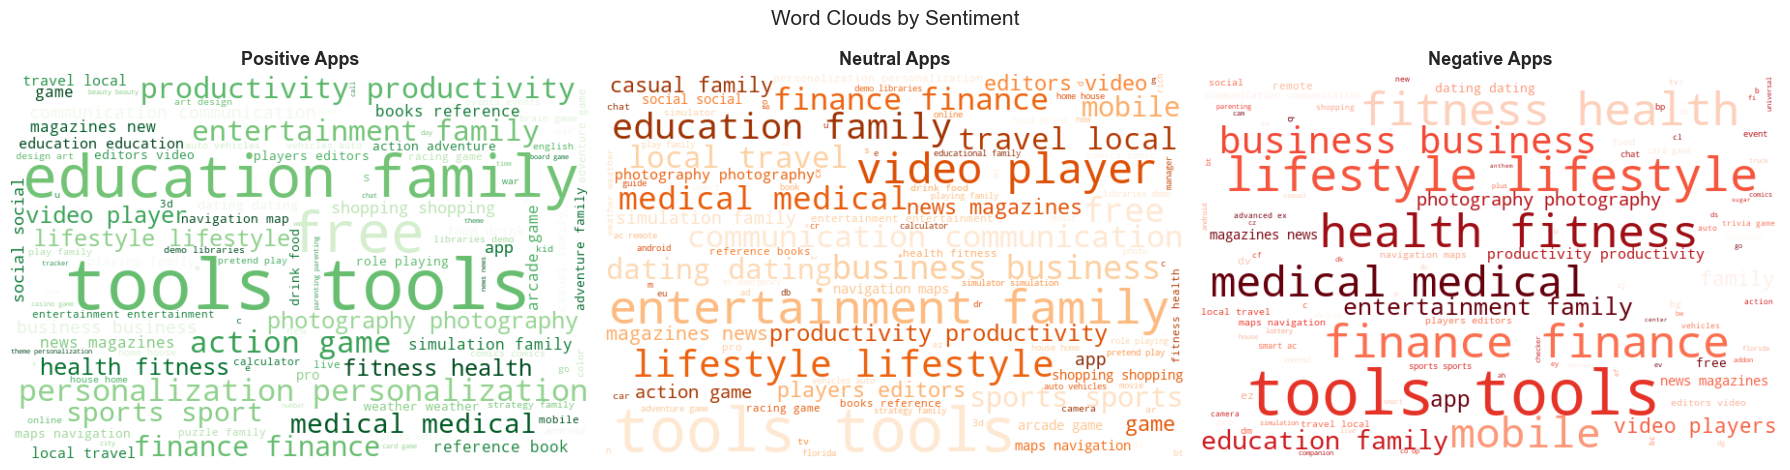

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = ['Positive', 'Neutral', 'Negative']
palette = ['Greens', 'Oranges', 'Reds']

for ax, sentiment, cmap in zip(axes, sentiments, palette):
    text = ' '.join(df[df['Sentiment'] == sentiment]['text_feature'])
    wc = WordCloud(width=600, height=400, colormap=cmap, background_color='white',
                   max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment} Apps', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=15)
plt.tight_layout()
plt.show()

### 5.3 TF-IDF Vectorization

In [11]:
# Encode sentiment labels to integers
le = LabelEncoder()
df['label'] = le.fit_transform(df['Sentiment'])

X = df['text_feature']
y = df['label']

# TF-IDF: converts text into weighted numeric feature vectors
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')

# Split before fitting to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit on train only
X_test_tfidf  = tfidf.transform(X_test)        # transform test

print(f'Training samples : {X_train_tfidf.shape[0]}')
print(f'Test samples     : {X_test_tfidf.shape[0]}')
print(f'Feature matrix   : {X_train_tfidf.shape}')

Training samples : 6556
Test samples     : 1640
Feature matrix   : (6556, 5000)


## 6. Model Training & Evaluation

### 6.1 Naive Bayes Classifier

In [12]:
# Train Multinomial Naive Bayes — fast, works well with TF-IDF text features
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print('=== Naive Bayes Results ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}')
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

=== Naive Bayes Results ===
Accuracy: 0.7683
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        56
     Neutral       0.45      0.05      0.09       326
    Positive       0.78      0.99      0.87      1258

    accuracy                           0.77      1640
   macro avg       0.41      0.35      0.32      1640
weighted avg       0.68      0.77      0.69      1640



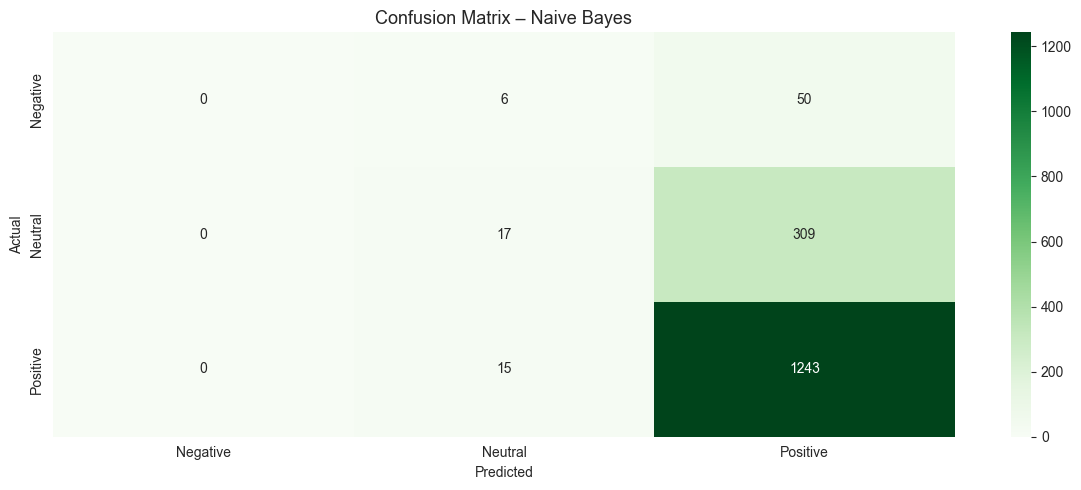

In [13]:
# Confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – Naive Bayes', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 6.2 Support Vector Machine (SVM)

In [14]:
# LinearSVC — effective for high-dimensional text classification
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print('=== SVM Results ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

=== SVM Results ===
Accuracy: 0.7579
              precision    recall  f1-score   support

    Negative       0.18      0.04      0.06        56
     Neutral       0.41      0.19      0.26       326
    Positive       0.80      0.94      0.86      1258

    accuracy                           0.76      1640
   macro avg       0.46      0.39      0.39      1640
weighted avg       0.70      0.76      0.71      1640



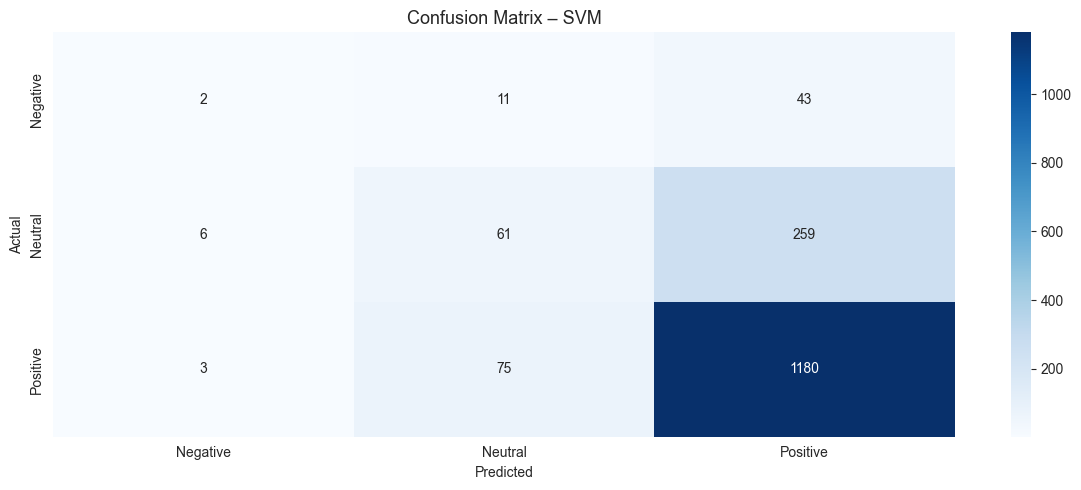

In [15]:
# Confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – SVM', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 6.3 Model Comparison

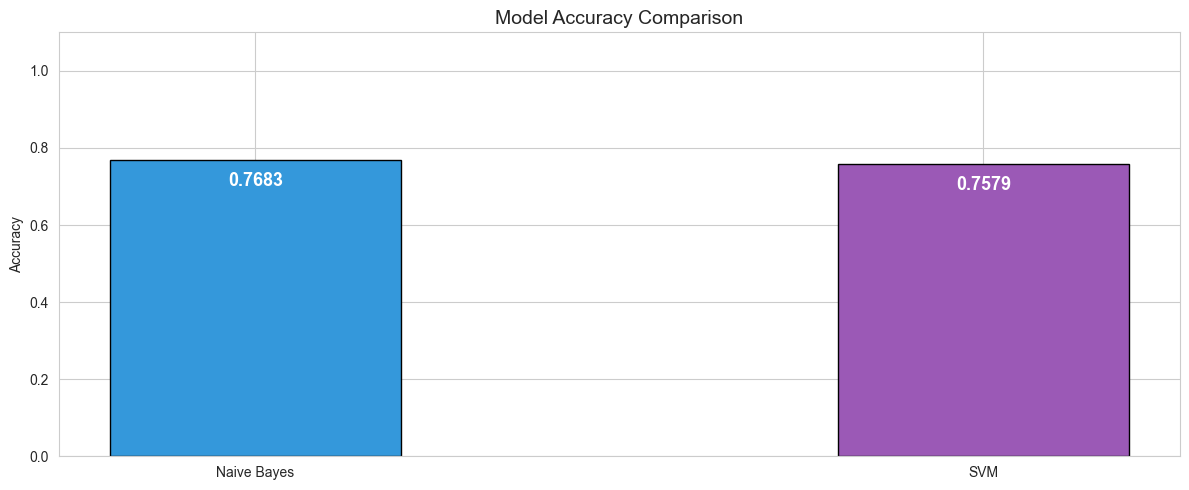

In [16]:
# Compare accuracy of both models
models = ['Naive Bayes', 'SVM']
accuracies = [
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm)
]

colors = ['#3498db', '#9b59b6']
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.4)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.03,
             f'{acc:.4f}', ha='center', va='top', color='white', fontweight='bold', fontsize=13)

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 7. Data Visualization & Insights

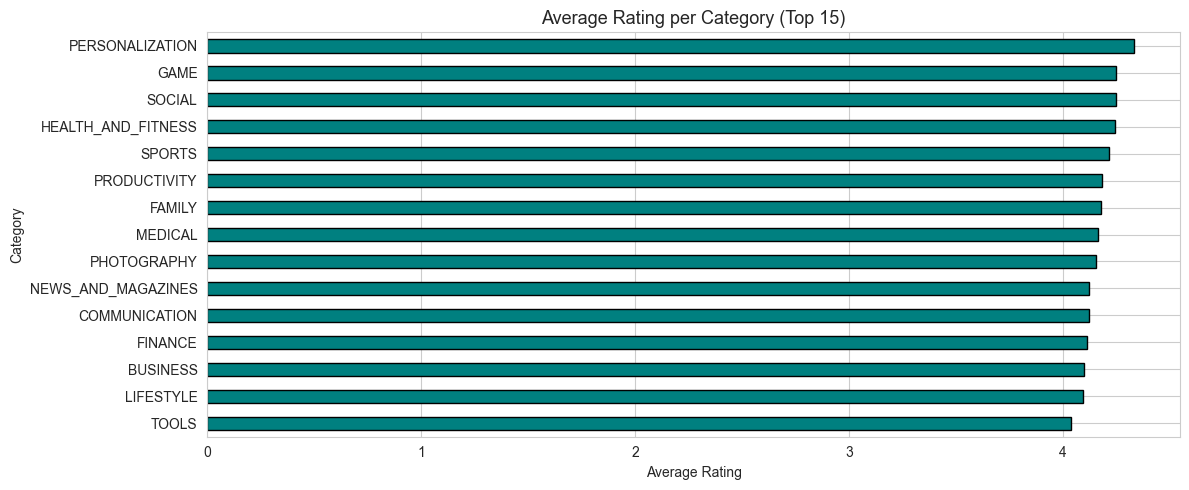

In [17]:
# Average rating per category (top 15 categories by count)
top_cats = df['Category'].value_counts().head(15).index
avg_ratings = df[df['Category'].isin(top_cats)].groupby('Category')['Rating'].mean().sort_values()

avg_ratings.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Average Rating per Category (Top 15)', fontsize=13)
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

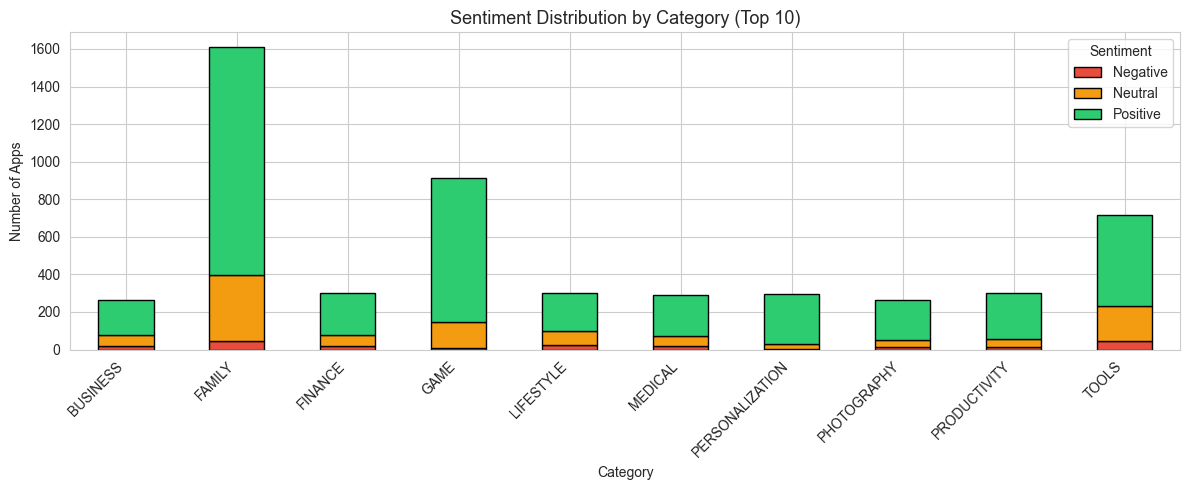

In [18]:
# Sentiment distribution per category (top 10)
top10 = df['Category'].value_counts().head(10).index
cat_sent = df[df['Category'].isin(top10)].groupby(['Category', 'Sentiment']).size().unstack(fill_value=0)

cat_sent.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
plt.title('Sentiment Distribution by Category (Top 10)', fontsize=13)
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

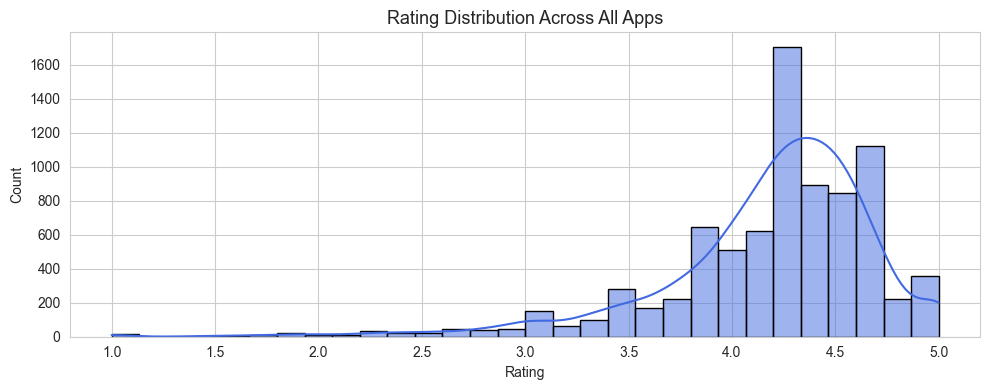

In [19]:
# Rating distribution histogram
plt.figure(figsize=(10, 4))
sns.histplot(df['Rating'], bins=30, kde=True, color='royalblue', edgecolor='black')
plt.title('Rating Distribution Across All Apps', fontsize=13)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

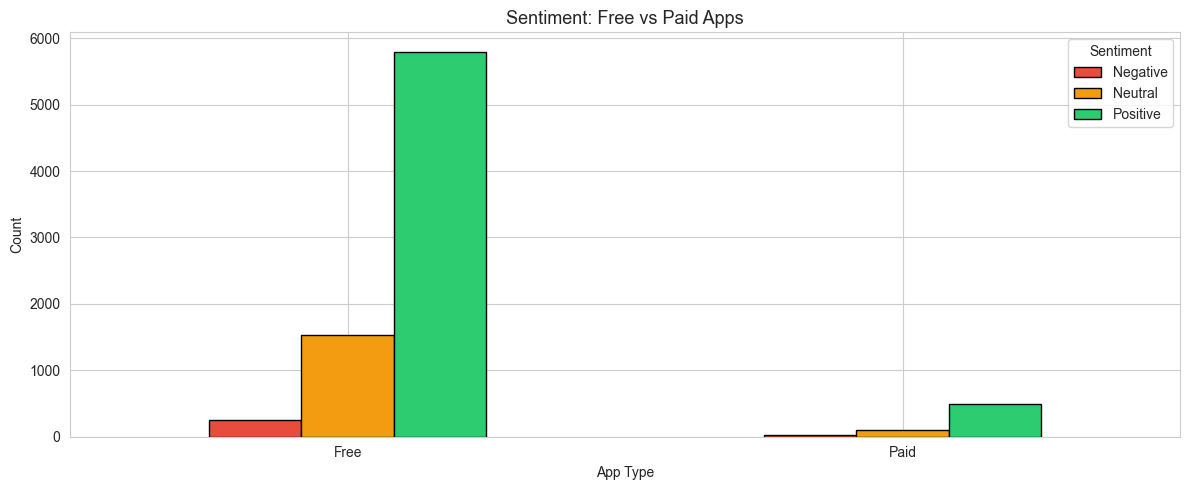

In [20]:
# Free vs Paid sentiment comparison
free_paid = df.groupby(['Type', 'Sentiment']).size().unstack(fill_value=0)

free_paid.plot(kind='bar', color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
plt.title('Sentiment: Free vs Paid Apps', fontsize=13)
plt.xlabel('App Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## 8. Predict Sentiment on New App Name

In [21]:
def predict_sentiment(app_name, model=svm_model):
    """Predict sentiment for a new app name using the trained SVM model."""
    cleaned = clean_text(app_name)
    vectorized = tfidf.transform([cleaned])
    pred = model.predict(vectorized)[0]
    return le.inverse_transform([pred])[0]

# Test with sample app names
samples = [
    'Best Photo Editor Pro',
    'Virus Remover & Cleaner',
    'Kids Learning Game Fun'
]

print('--- Sentiment Predictions ---')
for app in samples:
    print(f'App: "{app}"  →  Sentiment: {predict_sentiment(app)}')

--- Sentiment Predictions ---
App: "Best Photo Editor Pro"  →  Sentiment: Positive
App: "Virus Remover & Cleaner"  →  Sentiment: Positive
App: "Kids Learning Game Fun"  →  Sentiment: Positive


## 9. Summary

| Item | Detail |
|------|--------|
| Dataset | Google Play Store – 9,660 apps |
| Sentiment Labels | Derived from `Rating` (Positive / Neutral / Negative) |
| Text Feature | App Name + Genre + Category (TF-IDF, 5000 features, bigrams) |
| Model 1 | Multinomial Naive Bayes |
| Model 2 | Linear SVM (`LinearSVC`) |
| Best Model | SVM (generally higher accuracy on sparse TF-IDF features) |

> **Note:** For production-grade sentiment analysis, having actual user review text (e.g., from the Google Play reviews dataset) would allow models like BERT or VADER to achieve much higher accuracy.